In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1

## 1

In [396]:
def LCG(x0: int,a: int,c: int,M, k):
    U = [x0]
    for _ in range(k):
        x0 = (a*x0+c)%M
        U.append(x0)
    return np.array(U)/M

### 1.a

In [397]:
k = 10000 #number of random numbers
x0 = 42 #seed
a = 16807
c = 0
M = 2**31-1

U = LCG(x0,a,c,M,k)

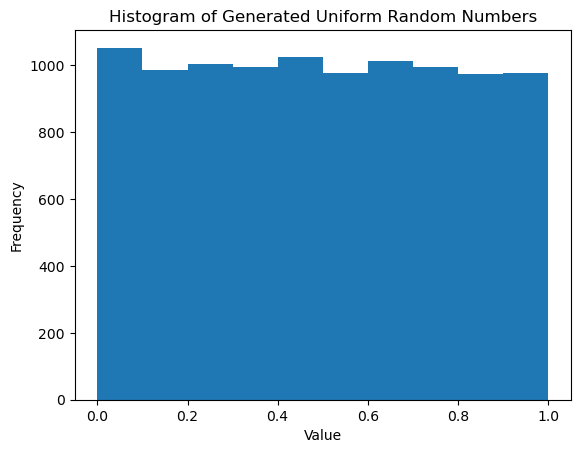

In [398]:
plt.hist(U, bins = 10)
plt.title("Histogram of Generated Uniform Random Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### 1.b

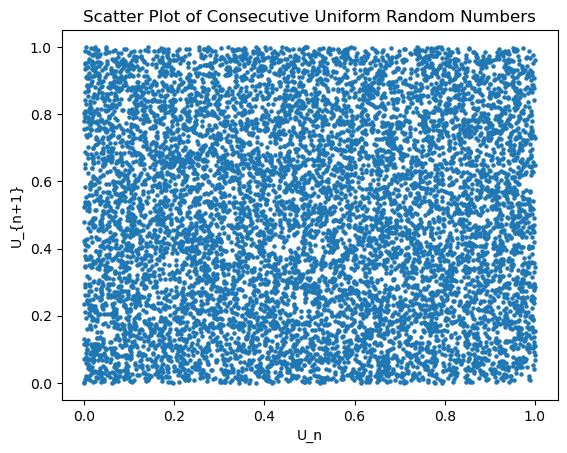

In [399]:
plt.scatter(U[:-1],U[1:], s=5)
plt.title("Scatter Plot of Consecutive Uniform Random Numbers")
plt.xlabel('U_n')
plt.ylabel('U_{n+1}')
plt.show()

In [378]:
#X2 test
bins = 10
expected = k/bins
observed, _ = np.histogram(U, bins=bins, range=(0,1))
T = np.sum((observed - expected)**2 / expected) 

print(f"Chi-squared test statistic: {T:.2f}")

#df = bins - 1 - m
df = bins - 1 - 0 
print(f"Degrees of freedom: {df}")
chi_critical_value = 16.919 #chi-squared critical value for df=9 at p = 0.95 => alpha=0.05 (from formelsamling)

if T < chi_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.") 

Chi-squared test statistic: 5.49
Degrees of freedom: 9
Fail to reject null hypothesis: data is uniformly distributed.


Kolmogorov-Smirnov test statistic: 0.01


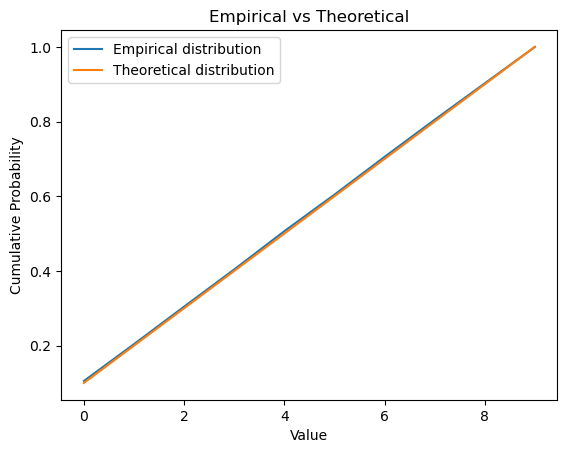

In [379]:
#Kolmogorov-Smirnov test
F_empirical = np.cumsum(observed)/k
F_theoretical = np.cumsum([expected]*bins)/k
D = np.max(np.abs(np.array(F_empirical) - np.array(F_theoretical)))
print(f"Kolmogorov-Smirnov test statistic: {D:.2f}")

plt.plot(F_empirical, label='Empirical distribution')
plt.plot(F_theoretical, label='Theoretical distribution')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title("Empirical vs Theoretical")
plt.legend()
plt.show()

In [308]:
#Adjusted test statistic
#n is the number of samples, k in our case
k = k+1
adjust_stat = (np.sqrt(k)+0.12+ (0.11/np.sqrt(k)))*D

kol_critical_val =1.358 #from slides with alpha = 0.05
print(f"Adjusted Kolmogorov-Smirnov test statistic: {adjust_stat:.2f}")

if adjust_stat < kol_critical_val:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.") 


Adjusted Kolmogorov-Smirnov test statistic: 0.65
Fail to reject null hypothesis: data is uniformly distributed.


In [311]:
# run tests |
#Wald-Wolfowitz
median = np.median(U)
n1 = np.sum(U>median)
n2 = np.sum(U<=median)

mean = 2*(n1*n2/(n1+n2))+1
variance  = 2 * (
    n1*n2*(2*n1*n2 - n1 - n2)
    / ((n1+n2)**2 * (n1+n2 - 1))
)


# Remove observations equal to median
x2 = U[U != median]

labels = (x2 > median).astype(int)

# Count runs
T = 1
for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        T += 1

#standardize test statistic
Z = (T-mean)/np.sqrt(variance)

print(f"number of runs: {T}")
print(f"mean: {mean:.2f}")
print(f"variance: {variance:.2f}")
print(f"standardized test statistic: {Z:.2f}")

#since standrd normal distribution 
wald_critical_value = 1.96 #for alpha = 0.05
if abs(Z) < wald_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.")

number of runs: 5013
mean: 5001.50
variance: 2500.00
standardized test statistic: 0.23
Fail to reject null hypothesis: data is uniformly distributed.


In [312]:
#run test ||
#knudth test
index = [0]
count = 1
for i in range(1,len(U)):
    if U[i] < U[i-1]:
        count+=1
        index.append(i)

index.append(i)
length = np.diff(index)

print(f"number of runs: {count}")
print(f"lengths of runs: {length}")
np.shape(length)

number of runs: 4975
lengths of runs: [4 2 2 ... 2 1 1]


(4975,)

In [313]:
R = np.zeros(6).astype(int)

R[0] = int(np.sum(length==1))
R[1] = int(np.sum(length==2))
R[2] = int(np.sum(length==3))
R[3] = int(np.sum(length==4))
R[4] = int(np.sum(length==5))
R[5] = int(np.sum(length>5))
R

array([1645, 2073,  909,  273,   62,   13])

In [314]:
B = np.array([1/6,5/24,11/120,19/720,29/5040,1/840])

A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])

k = 10001
Z = 1/(k-6)*(R - k*B).T @ A @ (R - k*B)
print(f"Knuth's test statistic: {Z:.2f}")

#chicritical value for df = 6 at alpha = 0.05
chi_run_critical_value = 12.592

if Z < chi_run_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.")

Knuth's test statistic: 1.46
Fail to reject null hypothesis: data is uniformly distributed.


In [315]:
#correlation test
h = 4

# Calculate the estimated correlation (ch)
c = (1 / (k - h)) * sum(U[i] * U[i + h] for i in range(k - h))
print(f"Correlation for h={h}: {c:.4f}")

expected_mean = 0.25
variance = 7 / (144 * k)     
std_dev = np.sqrt(variance)


Z = (c - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")

critical_value = 1.96  # for alpha = 0.05

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation.")

Correlation for h=4: 0.2466
Standardized correlation test statistic: -1.52
Fail to reject H0: No significant evidence of correlation (behaves like true white noise).


### 1.c

In [390]:
def LCG(x0: int,a: int,c: int,M, k):
    U = [x0]
    for _ in range(k):
        x0 = (a*x0+c)%M
        U.append(x0)
    return np.array(U)/M

In [391]:
k = 10000 #number of random numbers
x0 = 42 #seed
a = 100
c = 5
M = 2**16-1

U = LCG(x0,a,c,M,k)

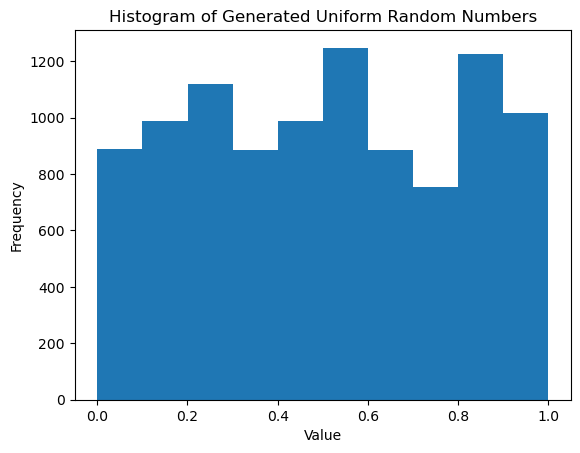

In [392]:
plt.hist(U, bins = 10)
plt.title("Histogram of Generated Uniform Random Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

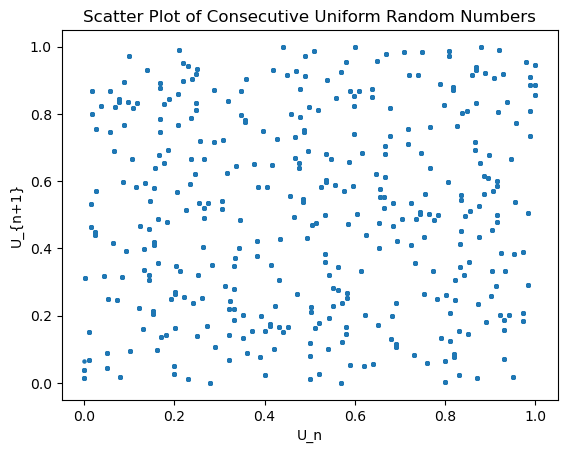

In [395]:
plt.scatter(U[:-1],U[1:], s=5)
plt.title("Scatter Plot of Consecutive Uniform Random Numbers")
plt.xlabel('U_n')
plt.ylabel('U_{n+1}')
plt.show()

In [384]:
#X2 test
bins = 10
expected = len(U)/bins
observed, _ = np.histogram(U, bins=bins)
T = np.sum((observed - expected)**2 / expected) 

print(f"Chi-squared test statistic: {T:.2f}")

#df = bins - 1 - m
df = bins - 1 - 0 
print(f"Degrees of freedom: {df}")
chi_critical_value = 16.919 #chi-squared critical value for df=9 at p = 0.95 => alpha=0.05 (from formelsamling)

if T < chi_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.") 

Chi-squared test statistic: 224.67
Degrees of freedom: 9
Reject null hypothesis: data is not uniformly distributed.


Kolmogorov-Smirnov test statistic: 0.02


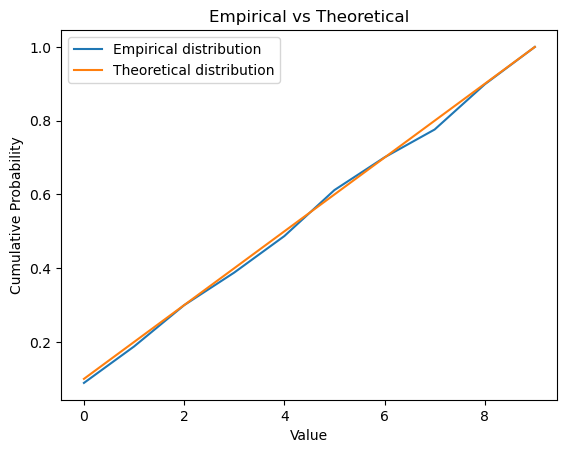

In [385]:
#Kolmogorov-Smirnov test
F_empirical = np.cumsum(observed)/k
F_theoretical = np.cumsum([expected]*bins)/k
D = np.max(np.abs(np.array(F_empirical) - np.array(F_theoretical)))
print(f"Kolmogorov-Smirnov test statistic: {D:.2f}")

plt.plot(F_empirical, label='Empirical distribution')
plt.plot(F_theoretical, label='Theoretical distribution')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title("Empirical vs Theoretical")
plt.legend()
plt.show()

In [343]:
#Adjusted test statistic
#n is the number of samples, k in our case
k = k+1
adjust_stat = (np.sqrt(k)+0.12+ (0.11/np.sqrt(k)))*D

kol_critical_val = 1.358 #from slides with alpha = 0.05
print(f"Adjusted Kolmogorov-Smirnov test statistic: {adjust_stat:.2f}")

if adjust_stat < kol_critical_val:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.") 


Adjusted Kolmogorov-Smirnov test statistic: 2.39
Reject null hypothesis: data is not uniformly distributed.


In [346]:
# run tests |
#Wald-Wolfowitz
median = np.median(U)
n1 = np.sum(U>median)
n2 = np.sum(U<median)

mean = 2*(n1*n2/(n1+n2))+1
variance  = 2 * (
    n1*n2*(2*n1*n2 - n1 - n2)
    / ((n1+n2)**2 * (n1+n2 - 1))
)


# Remove observations equal to median
x2 = U[U != median]

labels = (x2 > median).astype(int)

# Count runs
T = 1
for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        T += 1

#standardize test statistic
Z = (T-mean)/np.sqrt(variance)

print(f"number of runs: {T}")
print(f"mean: {mean:.2f}")
print(f"variance: {variance:.2f}")
print(f"standardized test statistic: {Z:.2f}")

#since standrd normal distribution 
wald_critical_value = 1.96 #for alpha = 0.05
if abs(Z) < wald_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.")

number of runs: 5000
mean: 4988.47
variance: 2493.47
standardized test statistic: 0.23
Fail to reject null hypothesis: data is uniformly distributed.


In [348]:
#run test ||
#knudth test
index = [0]
count = 1
for i in range(1,len(U)):
    if U[i] < U[i-1]:
        count+=1
        index.append(i)

index.append(i)
length = np.diff(index)

print(f"number of runs: {count}")
print(f"lengths of runs: {length}")
np.shape(length)

number of runs: 5130
lengths of runs: [5 1 1 ... 2 3 0]


(5130,)

In [ ]:
R = np.zeros(6).astype(int)

R[0] = int(np.sum(length==1))
R[1] = int(np.sum(length==2))
R[2] = int(np.sum(length==3))
R[3] = int(np.sum(length==4))
R[4] = int(np.sum(length==5))
R[5] = int(np.sum(length>5))

B = np.array([1/6,5/24,11/120,19/720,29/5040,1/840])

A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])

k = 10001
Z = 1/(k-6)*(R - k*B).T @ A @ (R - k*B)
print(f"Knuth's test statistic: {Z:.2f}")

#chicritical value for df = 6 at alpha = 0.05
chi_run_critical_value = 12.592 

if Z < chi_run_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.")

Knuth's test statistic: 54.46
Reject null hypothesis: data is not uniformly distributed.


In [351]:
#correlation test
h = 4

# Calculate the estimated correlation (ch)
c = (1 / (k - h)) * sum(U[i] * U[i + h] for i in range(k - h))
print(f"Correlation for h={h}: {c:.4f}")

expected_mean = 0.25
variance = 7 / (144 * k)     
std_dev = np.sqrt(variance)


Z = (c - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")

critical_value = 1.96  # for alpha = 0.05

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation.")

Correlation for h=4: 0.2566
Standardized correlation test statistic: 2.98
Reject H0: Significant evidence of correlation.


## 2

In [352]:
np.random.seed(42)  # Set seed for reproducibility
U = np.random.uniform(0,1,10001)

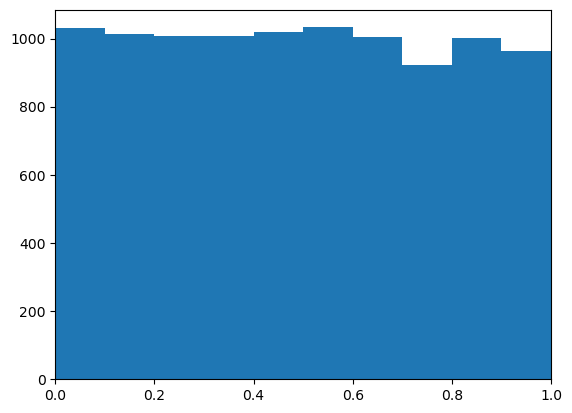

In [353]:
plt.hist(U, bins = 10)
plt.xlim(0,1)
plt.show()

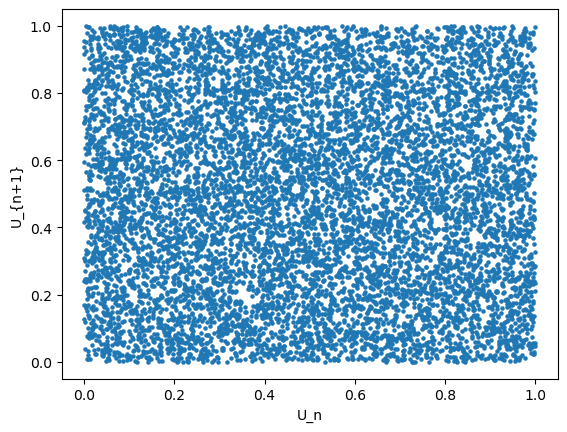

In [354]:
plt.scatter(U[:-1],U[1:], s=5)
plt.xlabel('U_n')
plt.ylabel('U_{n+1}')
plt.show()

In [355]:
#X2 test
bins = 10
expected = k/bins
observed, _ = np.histogram(U, bins=bins, range=(0,1))
T = np.sum((observed - expected)**2 / expected) 

print(f"Chi-squared test statistic: {T:.2f}")

#df = bins - 1 - m
df = bins - 1 - 0 
print(f"Degrees of freedom: {df}")
chi_critical_value = 16.919 #chi-squared critical value for df=9 at p = 0.95 => alpha=0.05 (from formelsamling)

if T < chi_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.") 

Chi-squared test statistic: 9.76
Degrees of freedom: 9
Fail to reject null hypothesis: data is uniformly distributed.


Kolmogorov-Smirnov test statistic: 0.01


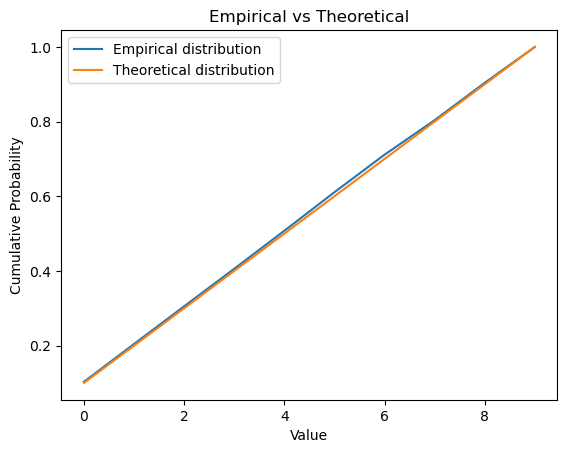

In [373]:
#Kolmogorov-Smirnov test
F_empirical = np.cumsum(observed)/k
F_theoretical = np.cumsum([expected]*bins)/k
D = np.max(np.abs(np.array(F_empirical) - np.array(F_theoretical)))
print(f"Kolmogorov-Smirnov test statistic: {D:.2f}")

plt.plot(F_empirical, label='Empirical distribution')
plt.plot(F_theoretical, label='Theoretical distribution')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title("Empirical vs Theoretical")
plt.legend()
plt.show()

In [357]:
#Adjusted test statistic
#n is the number of samples, k in our case
k = k+1
adjust_stat = (np.sqrt(k)+0.12+ (0.11/np.sqrt(k)))*D

kol_critical_val = 1.358 #from slides with alpha = 0.05
print(f"Adjusted Kolmogorov-Smirnov test statistic: {adjust_stat:.2f}")

if adjust_stat < kol_critical_val:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.") 


Adjusted Kolmogorov-Smirnov test statistic: 1.13
Fail to reject null hypothesis: data is uniformly distributed.


In [358]:
# run tests |
#Wald-Wolfowitz
median = np.median(U)
n1 = np.sum(U>median)
n2 = np.sum(U<median)

mean = 2*(n1*n2/(n1+n2))+1
variance  = 2 * (
    n1*n2*(2*n1*n2 - n1 - n2)
    / ((n1+n2)**2 * (n1+n2 - 1))
)


# Remove observations equal to median
x2 = U[U != median]

labels = (x2 > median).astype(int)

# Count runs
T = 1
for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        T += 1

#standardize test statistic
Z = (T-mean)/np.sqrt(variance)

print(f"number of runs: {T}")
print(f"mean: {mean:.2f}")
print(f"variance: {variance:.2f}")
print(f"standardized test statistic: {Z:.2f}")

#since standrd normal distribution 
wald_critical_value = 1.96 #for alpha = 0.05
if abs(Z) < wald_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.")

number of runs: 5061
mean: 5001.00
variance: 2499.75
standardized test statistic: 1.20
Fail to reject null hypothesis: data is uniformly distributed.


In [359]:
#run test ||
#knudth test
index = [0]
count = 1
for i in range(1,len(U)):
    if U[i] < U[i-1]:
        count+=1
        index.append(i)

index.append(i)
length = np.diff(index)

print(f"number of runs: {count}")
print(f"lengths of runs: {length}")
np.shape(length)

number of runs: 4998
lengths of runs: [2 1 1 ... 4 1 1]


(4998,)

In [360]:
R = np.zeros(6).astype(int)

R[0] = int(np.sum(length==1))
R[1] = int(np.sum(length==2))
R[2] = int(np.sum(length==3))
R[3] = int(np.sum(length==4))
R[4] = int(np.sum(length==5))
R[5] = int(np.sum(length>5))
R

array([1662, 2096,  900,  267,   60,   13])

In [361]:
B = np.array([1/6,5/24,11/120,19/720,29/5040,1/840])

A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])


Z = 1/(k-6)*(R - k*B).T @ A @ (R - k*B)
print(f"Knuth's test statistic: {Z:.2f}")

#chicritical value for df = 6 at alpha = 0.05
chi_run_critical_value = 12.592

if Z < chi_run_critical_value:
    print("Fail to reject null hypothesis: data is uniformly distributed.")
else:
    print("Reject null hypothesis: data is not uniformly distributed.")

Knuth's test statistic: 0.67
Fail to reject null hypothesis: data is uniformly distributed.


In [362]:
#correlation test
h = 4

# Calculate the estimated correlation (ch)
c = (1 / (len(U)- h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))
print(f"Correlation for h={h}: {c:.4f}")

expected_mean = 0.25
variance = 7 / (144 * len(U))     
std_dev = np.sqrt(variance)


Z = (c - expected_mean) / std_dev
print(f"Standardized correlation test statistic: {Z:.2f}")

critical_value = 1.96  # for alpha = 0.05

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation.")

Correlation for h=4: 0.2439
Standardized correlation test statistic: -2.75
Reject H0: Significant evidence of correlation.


## 3

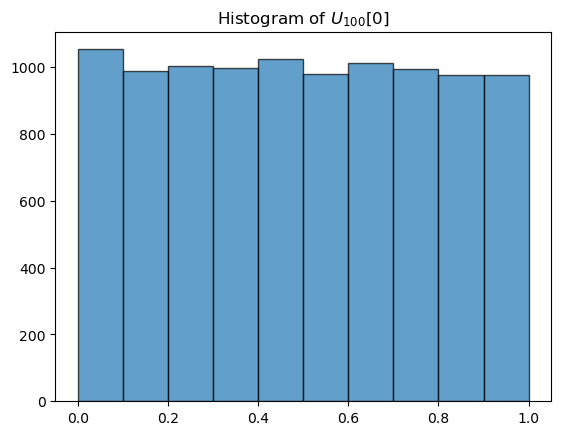

In [363]:
k = 10000 #number of random numbers
x0 = 42 #seed
a = 16807
c = 0
M = 2**31-1

U_100 = []
for i in range(100):
    U = LCG(x0, a, c, M, k)
    U_100.append(U)
    x0 = int(U[-1] * M) 

plt.hist(U_100[0], bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of $U_{100}[0]$')
plt.show()

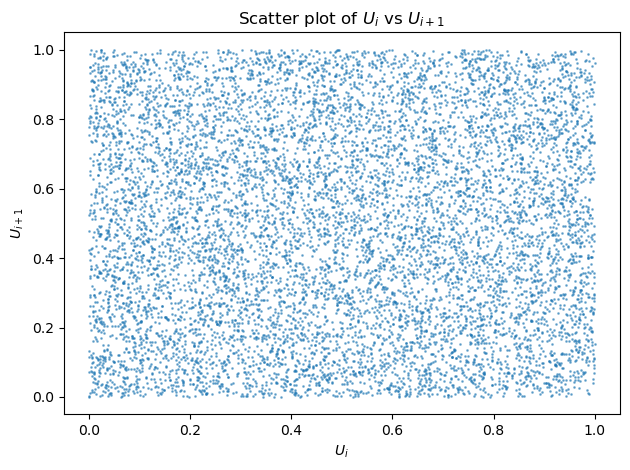

In [296]:
# Scatter plot: U_i vs U_{i+1}
plt.scatter(U_100[0][:-1], U_100[0][1:], s=1, alpha=0.5)
plt.title('Scatter plot of $U_i$ vs $U_{i+1}$')
plt.xlabel('$U_i$')
plt.ylabel('$U_{i+1}$')
plt.tight_layout()
plt.show()

In [ ]:
# X2 test
bins = 10
critical_value = 16.919 # from the formelsamling for df=9 at alpha=0.05

reject_count = 0
for U in U_100:
    observed, _ = np.histogram(U, bins)
    expected_class = len(U) / bins
    T = np.sum((observed - expected_class)**2 / expected_class)
    
    if T >= critical_value:
        reject_count += 1

print(f"Chi-Square Test: H0 rejected {reject_count} times out of 100.")

Chi-Square Test: H0 rejected 2 times out of 100.


In [ ]:
# Kolmogorov-Smirnov test
classes = 10
reject_count = 0

for U in U_100:
    observed, _ = np.histogram(U, classes)
    expected_class = len(U) / classes
    
    observed_cdf = np.cumsum(observed) / len(U)
    theoretical_cdf = np.cumsum([expected_class] * classes) / len(U)
    
    D = np.max(np.abs(observed_cdf - theoretical_cdf))
    adjusted_D = (np.sqrt(len(U)) + 0.12 + 0.11 / np.sqrt(len(U))) * D
    
    if adjusted_D >= 1.358: # Critical value for alpha=0.05 from slides 
        reject_count += 1

print(f"KS Test: H0 rejected {reject_count} times out of 100.")

KS Test: H0 rejected 5 times out of 100.


In [ ]:
# run test |
reject_count = 0

for U in U_100:
    median_U = np.median(U)
    runs_arr = np.array([1 if x > median_U else -1 for x in U if x != median_U])
    
    n1 = np.sum(runs_arr == 1)
    n2 = np.sum(runs_arr == -1)
    
    num_runs = 1
    for i in range(1, len(runs_arr)):
        if runs_arr[i] != runs_arr[i-1]:
            num_runs += 1
            
    n = n1 + n2
    expected_runs = (2 * n1 * n2) / n + 1
    var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))
    
    Z_runs = (num_runs - expected_runs) / np.sqrt(var_runs)
    
    if np.abs(Z_runs) >= 1.96:
        reject_count += 1

print(f"Run-Test I: H0 rejected {reject_count} times out of 100.")

Run-Test I: H0 rejected 5 times out of 100.


In [ ]:
# run-test ||
from collections import Counter
reject_count = 0

for U in U_100:
    run_lengths = []
    run_length = 1
    for i in range(1, len(U)):
        if U[i] < U[i-1]:
            run_lengths.append(run_length)
            run_length = 1
        else:
            run_length += 1
    run_lengths.append(run_length)

    run_lengths_bunched = [6 if length >= 6 else length for length in run_lengths]
    run_length_counts = Counter(run_lengths_bunched)
    R = np.array([run_length_counts.get(i, 0) for i in range(1, 7)])

    Z = 1 / len(U) * (R - len(U) * B).T @ A @ (R - len(U) * B)
    if Z >= 12.592:
        reject_count += 1

print(f"Run-Test II: H0 rejected {reject_count} times out of 100.")

Run-Test II: H0 rejected 9 times out of 100.


In [301]:
# correlation test
h = 4
expected_mean = 0.25
critical_value = 1.96  

reject_count = 0
for U in U_100:
    variance = 7 / (144 * len(U))
    std_dev = np.sqrt(variance)
    
    c = (1 / (len(U) - h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))
    Z = (c - expected_mean) / std_dev
    
    if abs(Z) >= critical_value:
        reject_count += 1
        
print(f"Correlation Test (h={h}): H0 rejected {reject_count} times out of 100.")

Correlation Test (h=4): H0 rejected 12 times out of 100.
